<a href="https://colab.research.google.com/github/juanjo2684/Aprendizaje_Automatico_Taller_20261/blob/main/Taller_%E2%80%94_Predicci%C3%B3n_de_accidentalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Diagnostico general y limpieza

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sqlite3
import pandas as pd

DB_PATH = '/content/drive/MyDrive/ml_trabajo2/data_accidentes.sqlite3'

con = sqlite3.connect(DB_PATH)
raw_accidentes = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])
accidentes = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
clima = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
con.close()

float_cols = clima.select_dtypes('float64').columns
clima[float_cols] = clima[float_cols].astype('float32')

for col in ['Mes', 'Dia', 'Hora']:
    accidentes[col] = accidentes[col].astype('int8')

clima['BARRIO'] = clima['BARRIO'].astype('category')
accidentes['BARRIO'] = accidentes['BARRIO'].astype('category')

print(raw_accidentes.shape, accidentes.shape, clima.shape)

(125122, 22) (120587, 8) (7991780, 15)


In [ ]:
for name, df in [('raw_accidentes', raw_accidentes), ('accidentes', accidentes), ('clima', clima)]:
    print(f'\n=== {name} ===')
    print(df.dtypes)
    print('Faltantes:\n', df.isna().sum()[df.isna().sum() > 0])
    print('Shape:', df.shape)


=== raw_accidentes ===
Lon                     float64
Lat                     float64
OBJECTID                  int64
RADICADO                 object
HORA                     object
Dia_sem                  object
PERIODO                   int64
CLASE                    object
DIRECCION                object
DIRECCION_ENC            object
CBML                     object
TIPO_GEOCOD              object
GRAVEDAD                 object
BARRIO                   object
COMUNA                   object
DISENO                   object
Mes                       int64
Dia                       int64
FECHA                    object
MES_NOMBRE               object
Hora_num                  int64
TW               datetime64[ns]
dtype: object
Faltantes:
 RADICADO          5
DISENO          429
MES_NOMBRE    82740
dtype: int64
Shape: (125122, 22)

=== accidentes ===
TW         datetime64[ns]
BARRIO           category
Lat               float64
Lon               float64
Dia_sem            object
Mes

In [ ]:
print('Duplicados (BARRIO, TW) en accidentes:', accidentes.duplicated(subset=['BARRIO', 'TW']).sum())
print('Duplicados (BARRIO, TW) en clima:', clima.duplicated(subset=['BARRIO', 'TW']).sum())

Duplicados (BARRIO, TW) en accidentes: 0
Duplicados (BARRIO, TW) en clima: 0


In [ ]:
barrios_acc = set(accidentes['BARRIO'].unique())
barrios_clima = set(clima['BARRIO'].unique())
print('Barrios en accidentes pero no en clima:', len(barrios_acc - barrios_clima))
print('Barrios en clima pero no en accidentes:', len(barrios_clima - barrios_acc))

print('Rango temporal accidentes', accidentes['TW'].min(), '-' , accidentes['TW'].max())
print('Rango temporal clima', clima['TW'].min(), '-', clima['TW'].max())

Barrios en accidentes pero no en clima: 3
Barrios en clima pero no en accidentes: 0
Rango temporal accidentes 2017-01-01 00:00:00 - 2019-12-31 23:00:00
Rango temporal clima 2017-01-01 00:00:00 - 2019-12-31 23:00:00


In [ ]:
clima.select_dtypes('number').describe().T[['min', 'max', 'mean', 'std']]

,min,max,mean,std
precipIntensity,0.000,20.823601,0.476144,0.889163
precipProbability,0.000,1.000000,0.159590,0.220214
temperature,4.510,35.990002,19.653791,3.751609
apparentTemperature,4.510,38.060001,19.727207,3.756107
dewPoint,2.160,24.040001,14.338623,2.025355
humidity,0.170,1.000000,0.734361,0.155642
windSpeed,0.000,15.260000,1.582618,1.244687
windBearing,0.000,359.000000,111.328651,80.282356
cloudCover,0.000,1.000000,0.722432,0.208432
uvIndex,0.000,14.000000,2.004863,2.849118


In [ ]:
clima.groupby(clima['windBearing'].isna())['windSpeed'].describe()

,count,mean,std,min,25%,50%,75%,max
windBearing,,,,,,,,
False,6959267.0,1.786672,1.193471,0.0,0.99,1.5,2.23,15.26
True,999720.0,0.162160,0.440893,0.0,0.00,0.0,0.00,4.11


In [ ]:
clima[['precipIntensity', 'precipProbability', 'windBearing']] = clima[
    ['precipIntensity', 'precipProbability', 'windBearing']
].fillna(0)

cols_drop = ['OBJECTID', 'RADICADO', 'CBML', 'TIPO_GEOCOD', 'DIRECCION_ENC', 'MES_NOMBRE']
raw_accidentes = raw_accidentes.drop(columns=cols_drop)

barrios_validos = set(clima['BARRIO'].unique())
accidentes = accidentes[accidentes['BARRIO'].isin(barrios_validos)].copy()

for df in [raw_accidentes, accidentes, clima]:
    df['BARRIO'] = df['BARRIO'].str.strip().str.upper()

print('Shape accidentes:', accidentes.shape)
print('Barrios únicos consistentes:', accidentes['BARRIO'].nunique(), '/', clima['BARRIO'].nunique())

Shape accidentes: (120583, 8)
Barrios únicos consistentes: 319 / 319


## 1.1 Resumen de decisiones

- Tablas cargadas desde SQLite con parse_dates=['TW'] para garantizar tipos correctos
- Se optimizaron tipos de datos: variables climaticas float64 a float32 y BARRIO a category para reducir uso de memoria.
- No se detectaron duplicados
- Rangos coincidentes entre accidentes y clima
- 3 barrios que estan en la tabla accidentes pero no se encuentran en la tabla clima. Se decidio prescindir de ellos.
- No se encontraron barrios que esten en clima y no esten en accidentes.
- precipIntensity y precipProbability con valores faltantes imputados a 0 (dias sin lluvia).
- windBearing faltantes inputados a cero luego de verificar que coinciden con windSpeed cercano a 0.
- Eliminacion de columnas no informativas de raw_accidentes incluyen OBJECTID, RADICADO, CBML, TIPO_GEOCOD, DIRECCION_ENC y MES_NOMBRE.
- No se detectaron valores atipicos. Los valores extremos observados son plausibles para las condiciones climaticas de Medellin.

# 2. EDA

## 2.1 Tasa positivos

In [ ]:
total = clima[['BARRIO', 'TW']].drop_duplicates().shape[0]
postivos = accidentes[['BARRIO', 'TW']].drop_duplicates().shape[0]
print(f'Tasa positivos: {postivos/total:.2%}')

Tasa positivos: 1.51%


## 2.2 Distribucion temporal accidentes

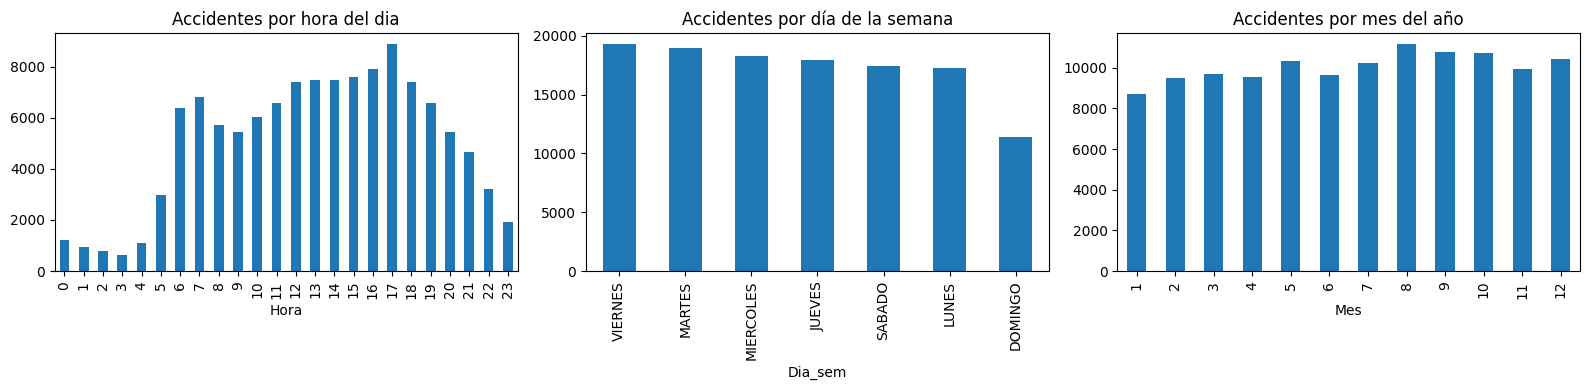

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
accidentes['Hora'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Accidentes por hora del dia')
accidentes['Dia_sem'].value_counts().plot(kind='bar', ax=axes[1], title='Accidentes por día de la semana')
accidentes['Mes'].value_counts().sort_index().plot(kind='bar', ax=axes[2], title='Accidentes por mes del año')
plt.tight_layout()
plt.show()

## 2.3 Distribucion de accidentes por barrios

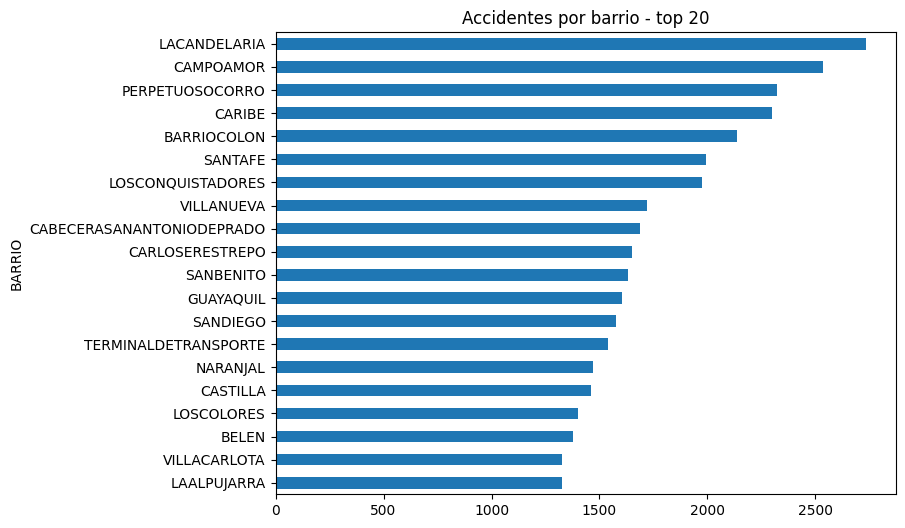

In [ ]:
accidentes['BARRIO'].value_counts().head(20).plot(kind='barh', figsize=(8, 6), title='Accidentes por barrio - top 20')
plt.gca().invert_yaxis()
plt.show()

## 2.4 Tipo de accidente

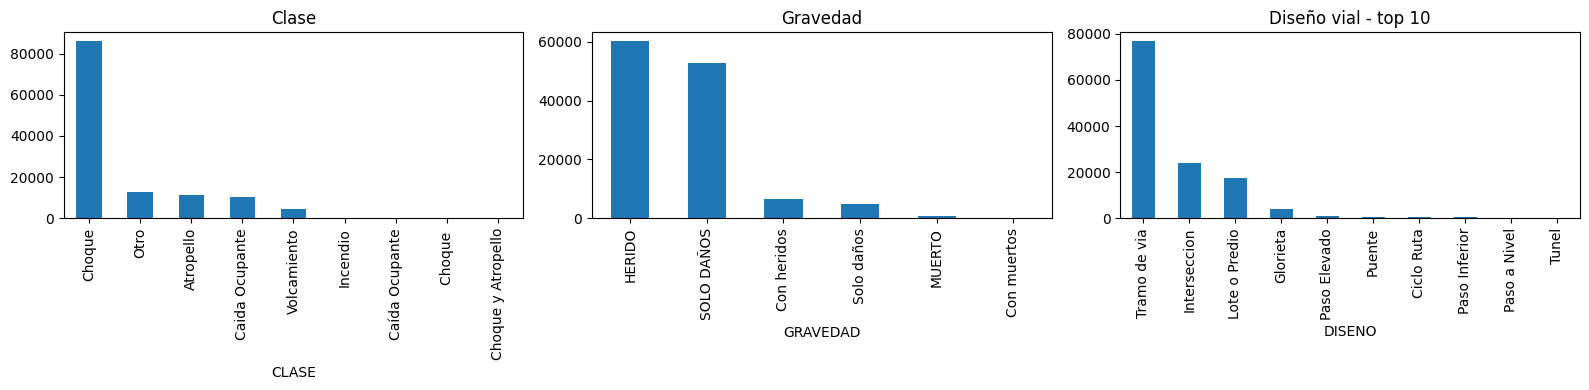

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
raw_accidentes['CLASE'].value_counts().plot(kind='bar', ax=axes[0], title='Clase')
raw_accidentes['GRAVEDAD'].value_counts().plot(kind='bar', ax=axes[1], title='Gravedad')
raw_accidentes['DISENO'].value_counts().head(10).plot(kind='bar', ax=axes[2], title='Diseño vial - top 10')
plt.tight_layout()
plt.show()

## 2.5 Tasa positiva por hora

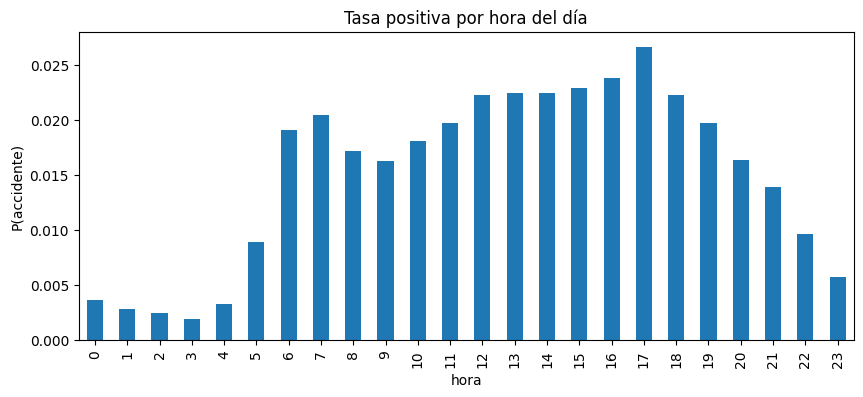

In [ ]:
clima_min = clima[['BARRIO', 'TW']].copy()
clima_min['hora'] = clima_min['TW'].dt.hour
clima_min['target'] = clima_min.set_index(['BARRIO', 'TW']).index.isin(accidentes.set_index(['BARRIO', 'TW']).index).astype(int)
clima_min.groupby('hora')['target'].mean().plot(kind='bar', figsize=(10, 4), title='Tasa positiva por hora del día')
plt.ylabel('P(accidente)')
plt.show()

## 2.6 Correlacion clima - accidentes

In [ ]:
clima_full = clima_min.merge(clima, on=['BARRIO', 'TW'], how='left')
clima_full.groupby('target')[['temperature', 'humidity', 'precipIntensity', 'windSpeed', 'visibility']].mean()

,temperature,humidity,precipIntensity,windSpeed,visibility
target,,,,,
0,19.624996,0.735288,0.443226,1.576782,11.316265
1,21.535631,0.673776,0.463434,1.963154,11.417221


In [ ]:
import matplotlib.pyplot as plt

def tasa_por_bins(serie, target, bins, titulo, ax):
    cat = pd.cut(serie, bins=bins, include_lowest=True)
    target.groupby(cat, observed=False).mean().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(titulo)
    ax.set_ylabel('Tasa positiva')
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

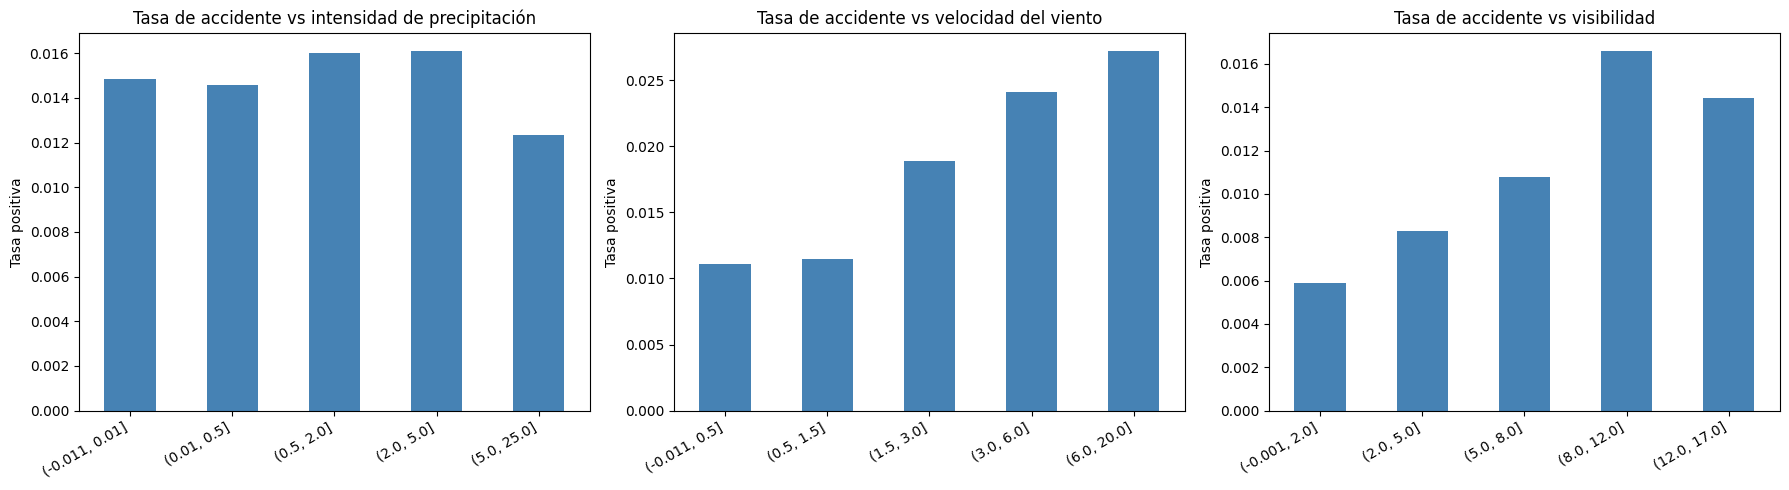

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tasa_por_bins(
    clima_full['precipIntensity'], clima_full['target'],
    bins=[-0.01, 0.01, 0.5, 2, 5, 25],
    titulo='Tasa de accidente vs intensidad de precipitación', ax=axes[0]
)
tasa_por_bins(
    clima_full['windSpeed'], clima_full['target'],
    bins=[-0.01, 0.5, 1.5, 3, 6, 20],
    titulo='Tasa de accidente vs velocidad del viento', ax=axes[1]
)
tasa_por_bins(
    clima_full['visibility'], clima_full['target'],
    bins=[0, 2, 5, 8, 12, 17],
    titulo='Tasa de accidente vs visibilidad', ax=axes[2]
)
plt.tight_layout()
plt.show()

## 2.7 Mapa de calor hora - dia

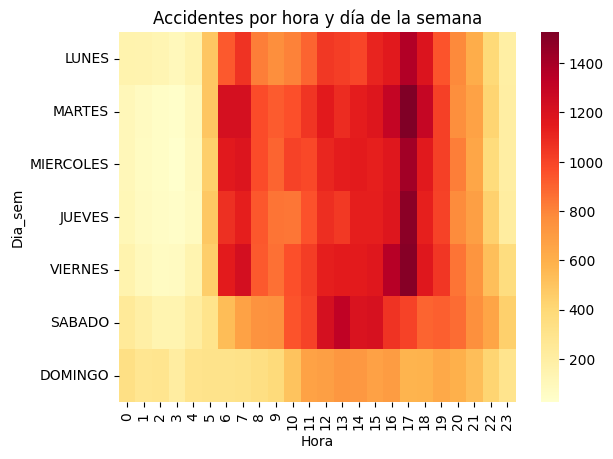

In [ ]:
import seaborn as sns
pivot = accidentes.pivot_table(index='Dia_sem', columns='Hora', values='BARRIO', aggfunc='count')
orden = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']
sns.heatmap(pivot.reindex(orden), cmap='YlOrRd')
plt.title('Accidentes por hora y día de la semana')
plt.show()


## 2.8 Hallazgos EDA

- Se confirma desbalanceo de clases. Clase positiva representa el 1.5% sobre cerca de 8M de registros.
- Accidentalidad presenta patron diurno con actividad alta entre 6am y 7pm, con pico a las 5pm.
- Mayor accidentalidad en dias laborales, principalmente dia viernes. Menor accidentalidad los dias domingos.
- Hay variabilidad en relacion a la temporalidad, lo que las justifica como features predictivas.
- La mayor accidentalidad la concentran los barrios La andelaria y Campoamor.
- La tasa positiva varia bastante entre horas, sinedo baja en la madrugada y alta en horas diurnas, con incrementos en horas pico.
- Las medias por clase en condiciones climaticas muestran diferencias leves que no permiten hacer una discriminacion clara.
- El analisis de tasa positiva por rangos muestra algunos patrones como incrementos en presencia de lluvias moderadas y vientos fuertes. Se justifica la creacion de indicadores de condiciones binarios principalmente para lluvia y viento.
- Mapa de calor confirma mayor accidentalidad entre dias lunes y viernes, y entre las 6am y 7pm con incrementos en las horas pico.

# 3. Union de tablas e ingenieria de caracteristicas

## 3.1 Union de tablas

In [ ]:
df = clima.merge(accidentes[['BARRIO', 'TW']].assign(target=1), on=['BARRIO', 'TW'], how='left')
df['target'] = df['target'].fillna(0).astype('int8')
df.head()

,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility,target
0,2017-01-01 00:00:00,AGUASFRIAS,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004,0
1,2017-01-01 01:00:00,AGUASFRIAS,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004,0
2,2017-01-01 02:00:00,AGUASFRIAS,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,1.02,0.0,0.44,0.0,2.997,0
3,2017-01-01 03:00:00,AGUASFRIAS,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199,0
4,2017-01-01 04:00:00,AGUASFRIAS,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099,0


In [ ]:
print(df.shape)
print(f'Tasa positivos: {(df['target'] == 1).sum()/df.shape[0]:.2%}')
print(df['target'].dtype)

(7991780, 16)
Tasa positivos: 1.51%
int8


## 3.2 Variables temporales

In [ ]:
import numpy as np
import holidays

In [ ]:
festivos_co = pd.to_datetime(list(holidays.country_holidays('CO', years=range(2017, 2020))))
df['es_festivo'] = df['TW'].dt.normalize().isin(festivos_co).astype(int)

In [ ]:
df['hora'] = df['TW'].dt.hour
df['dia_sem'] = df['TW'].dt.dayofweek
df['mes'] = df['TW'].dt.month
df['dia'] = df['TW'].dt.day
df['es_finde'] = (df['dia_sem'] >=5).astype(int)
df['hora_pico'] = (df['hora'].isin([7, 8, 9, 17, 18, 19])).astype(int)
df['mes_invierno'] = (df['mes'].isin([4, 5, 10, 11])).astype(int)

df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)
df['mes'] = np.cos(2 * np.pi * df['mes'] / 12)
df['mes'] = np.sin(2 * np.pi * df['mes'] / 12)

df['dia_sem'] = np.sin(2 * np.pi * df['dia_sem'] / 7)
df['dia_sem'] = np.cos(2 * np.pi * df['dia_sem'] / 7)

df['doy'] = df['TW'].dt.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / 365)
df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / 365)
df = df.drop(columns=['doy'])

## 3.3 Variables climaticas

In [ ]:
df['lluvia_fuerte'] = (df['precipIntensity'] > 5).astype(int)
df['viento_fuerte'] = (df['windSpeed'] > 3).astype(int)
df['visibilidad_baja'] = (df['visibility'] < 5).astype(int)


## 3.4 Variables por barrio

In [ ]:
mapa_comuna = raw_accidentes[['BARRIO', 'COMUNA']].drop_duplicates(subset='BARRIO').set_index('BARRIO')['COMUNA'].to_dict()
df['COMUNA'] = df['BARRIO'].map(mapa_comuna).astype('category')

## 3.5 Manejo variables categoricas

In [ ]:
df['summary'] = df['summary'].astype('category')
df['icon'] = df['icon'].astype('category')

In [ ]:
df.groupby('icon', observed=True)['summary'].nunique()

,summary
icon,
clear-day,2
clear-night,2
cloudy,2
fog,1
partly-cloudy-day,3
partly-cloudy-night,3
rain,8
wind,3


In [ ]:
df = df.drop(columns=['summary'])
df.head()